In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import random
import urllib

In [52]:
path = "dogs/train"

In [53]:
def read_data(path, shuffle=True):
    classes = {}
    images = []
    labels = []

    for i, label in enumerate(sorted(os.listdir(path))):
        classes[i] = label
        for img_name in tqdm(os.listdir(os.path.join(path, label))):
            if not (img_name.endswith(".jpg") or img_name.endswith(".png") or
                    img_name.endswith(".webp") or img_name.endswith(".jpeg") or
                    img_name.endswith(".avif")):
                continue
            img_path = os.path.join(path, label, img_name)
            images.append(img_path)
            labels.append(i)

    if shuffle:
        indices = np.arange(len(images))
        np.random.shuffle(indices)
        images = [images[i] for i in indices]
        labels = [labels[i] for i in indices]

    return classes, images, labels

In [54]:
classes, img_paths, labels = read_data(path)

100%|██████████| 140/140 [00:00<00:00, 343594.24it/s]


In [55]:
classes

{0: 'Afghan_hound',
 1: 'Blenheim_spaniel',
 2: 'Chihuahua',
 3: 'Japanese_spaniel',
 4: 'Maltese_dog',
 5: 'Pekinese',
 6: 'Rhodesian_ridgeback',
 7: 'Shih_Tzu',
 8: 'papillon',
 9: 'toy_terrier'}

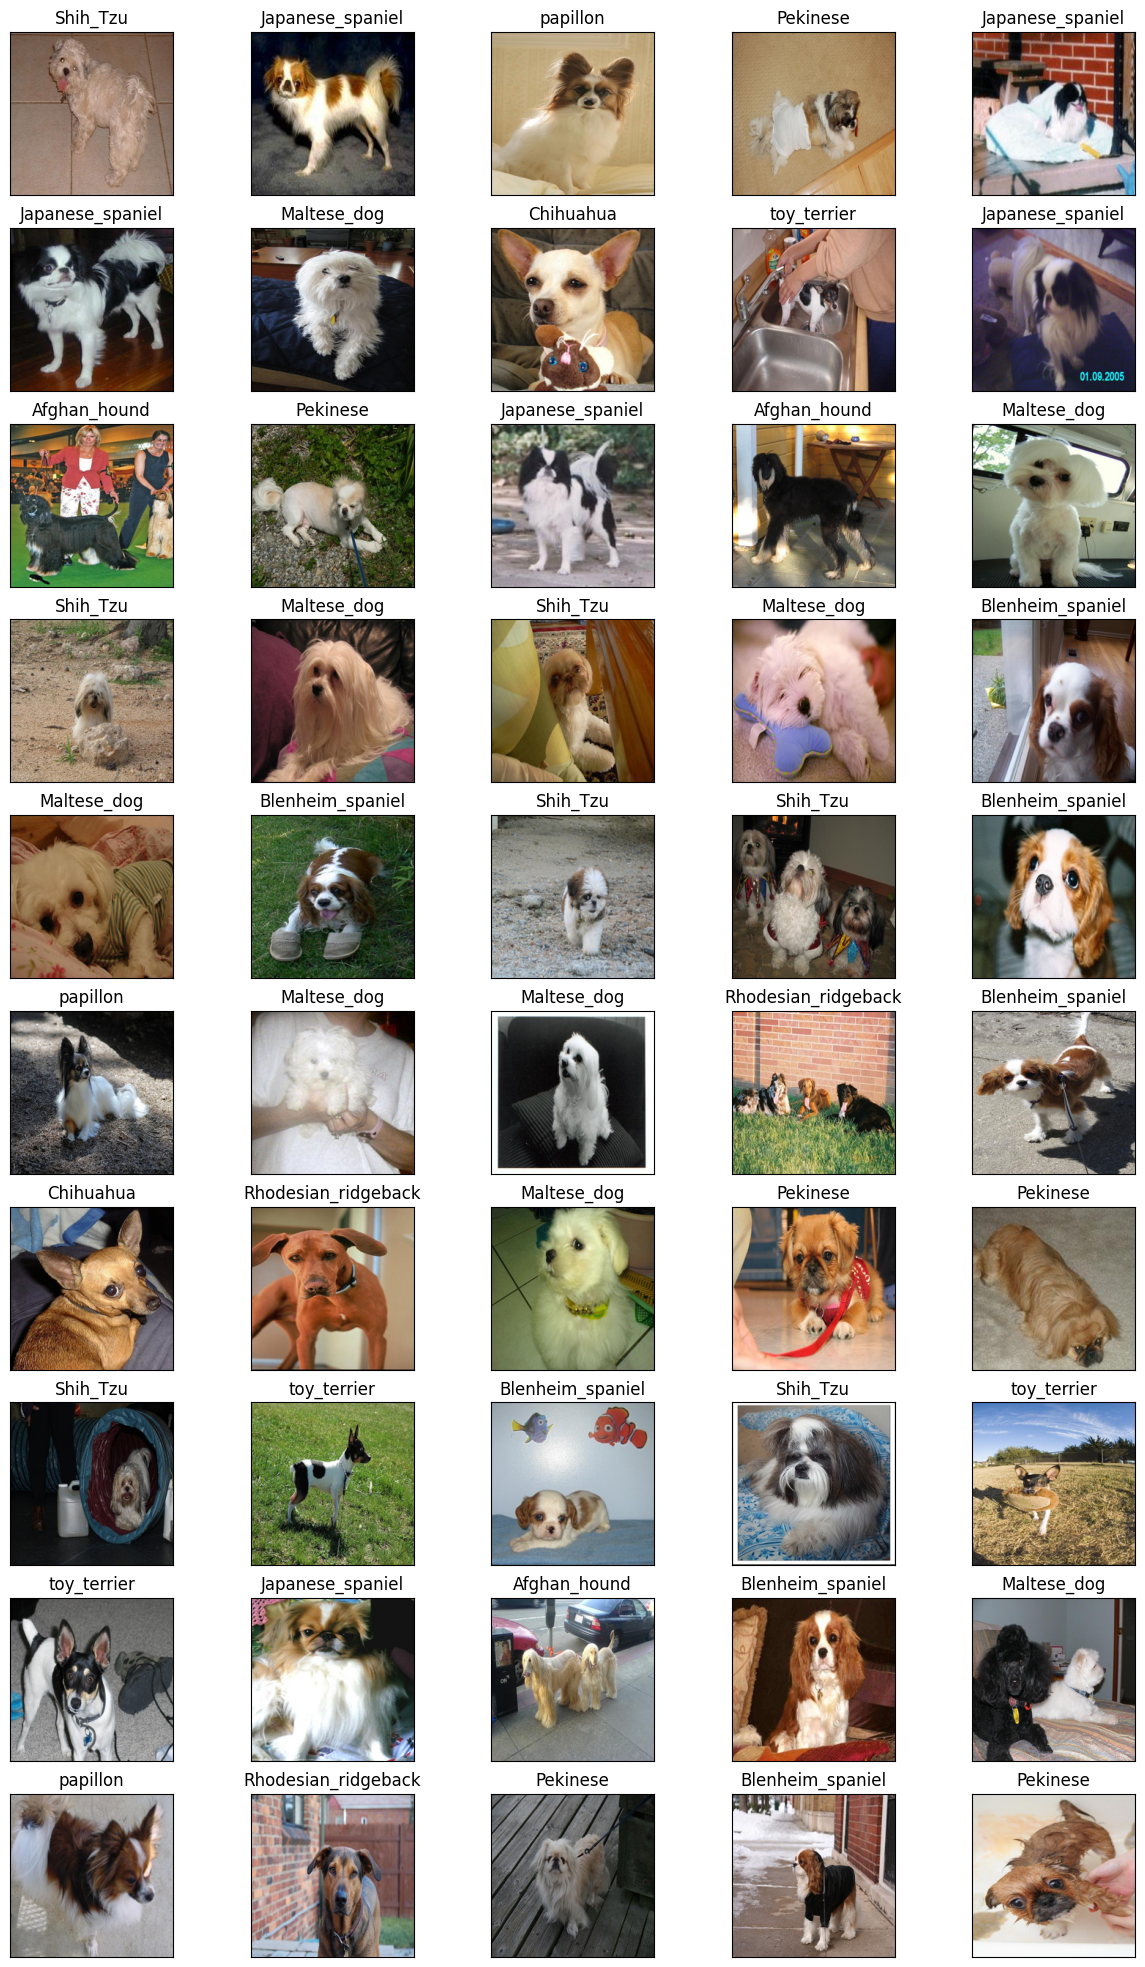

In [56]:
plt.figure(figsize=(15, 25))
index = random.sample(range(len(img_paths)), k=50)
ind = 0
for i in range(50):
    plt.subplot(10, 5, i + 1)
    img = Image.open(img_paths[ind]).resize((224, 224))
    lab = classes[labels[ind]]
    img = np.asarray(img)
    plt.imshow(img)
    plt.title(lab)
    plt.xticks([])
    plt.yticks([])
    ind += 1

In [57]:
x_train, x_test, y_train, y_test = train_test_split(img_paths, labels, test_size=0.2, random_state=42)

In [58]:
len(x_train), len(x_test)

(1281, 321)

In [74]:
class MyDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size=15, target_size=(224, 224), one_hot=False, num_classes=10):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.one_hot = one_hot
        self.num_classes = num_classes

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_paths = self.image_paths[index * self.batch_size : (index + 1) * self.batch_size]
        batch_labels = self.labels[index * self.batch_size : (index + 1) * self.batch_size]

        X = np.zeros((len(batch_paths), *self.target_size, 3), dtype="float32")
        y = np.array(batch_labels, dtype="int32")

        for i, path in enumerate(batch_paths):
            try:
                img = load_img(path, target_size=self.target_size, interpolation="bilinear")
                X[i] = tf.keras.applications.densenet.preprocess_input(img_to_array(img))
            except Exception as e:
                print(f"Error {path}: {e}")

        if self.one_hot:
            y = tf.keras.utils.to_categorical(y, num_classes=self.num_classes)

        return X, y

In [75]:
train = MyDataGenerator(x_train, y_train, batch_size=15, target_size=(224, 224), one_hot=True)
test = MyDataGenerator(x_test, y_test, batch_size=15, target_size=(224, 224), one_hot=True)

In [61]:
b0 = train[0]
b0[0].shape

(15, 224, 224, 3)

In [62]:
b0[1].shape

(15, 10)

In [63]:
m = tf.keras.applications.DenseNet201(include_top=False, input_shape=(224, 224, 3))

In [64]:
for layer in m.layers:
    layer.trainable = False

In [65]:
inp = Input(shape=(224, 224, 3))
nn = m(inp)
gap = GlobalAveragePooling2D()(nn)
d = Dense(128, activation="relu")(gap)
out = Dense(10, activation="softmax")(d)

model = tf.keras.Model(inp, out)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,569,162 (70.84 MB)

 Trainable params: 247,178 (965.54 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [66]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [67]:
model.fit(train, validation_data=test, epochs=3)

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


86/86 ━━━━━━━━━━━━━━━━━━━━ 125s 956ms/step - accuracy: 0.8517 - loss: 0.5063 - val_accuracy: 0.9159 - val_loss: 0.2437
Epoch 2/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.9703 - loss: 0.1005 - val_accuracy: 0.9315 - val_loss: 0.1884
Epoch 3/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.9781 - loss: 0.0726 - val_accuracy: 0.9221 - val_loss: 0.2248


In [26]:
def img_predict(img_link, model, is_img_link=True, k=3, size=(224, 224), expand=True):
    if is_img_link:
        img = np.asarray(Image.open(urllib.request.urlopen(img_link)).convert("RGB").resize(size))
    else:
        img = np.asarray(Image.open(img_link).convert("RGB").resize(size))
    plt.imshow(img)
    img = tf.keras.applications.densenet.preprocess_input(img)
    if expand:
        img = np.expand_dims(img, axis=0)
    p = model.predict(img)[0]
    y_p = p.argmax()
    ind = p.argsort()[::-1][:k]
    p.sort()
    vals = p[::-1][:k]
    for i, j in zip(ind, vals):
        # if j < 0.01:
            # break
        print(f"{classes[i]} - {j * 100:.5f}")
    return y_p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Chihuahua - 99.99677
toy_terrier - 0.00182
Blenheim_spaniel - 0.00043


np.int64(2)

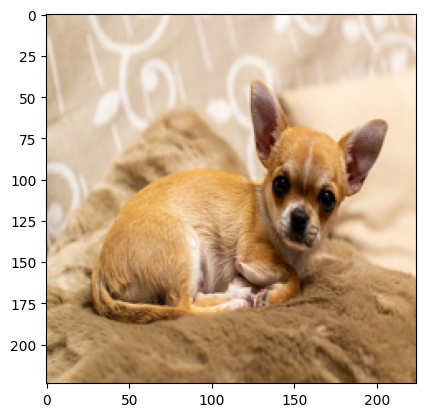

In [72]:
img_predict("https://miska.ru/upload/resize_cache/iblock/1a4/585_410_1/l62i0j0hb6d18xrwzn55ao4llcm2amxa.jpg", model, is_img_link=True)